In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import missingno as msno
from mpl_toolkits.mplot3d import Axes3D

<h1>Data Exploration</h1>

In [2]:
df=pd.read_csv(f'hotel_booking_course_release_v1_pack/hotel_bookings_course_release_v1.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


<h3>Checking Missing Values</h3>

In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

<Axes: >

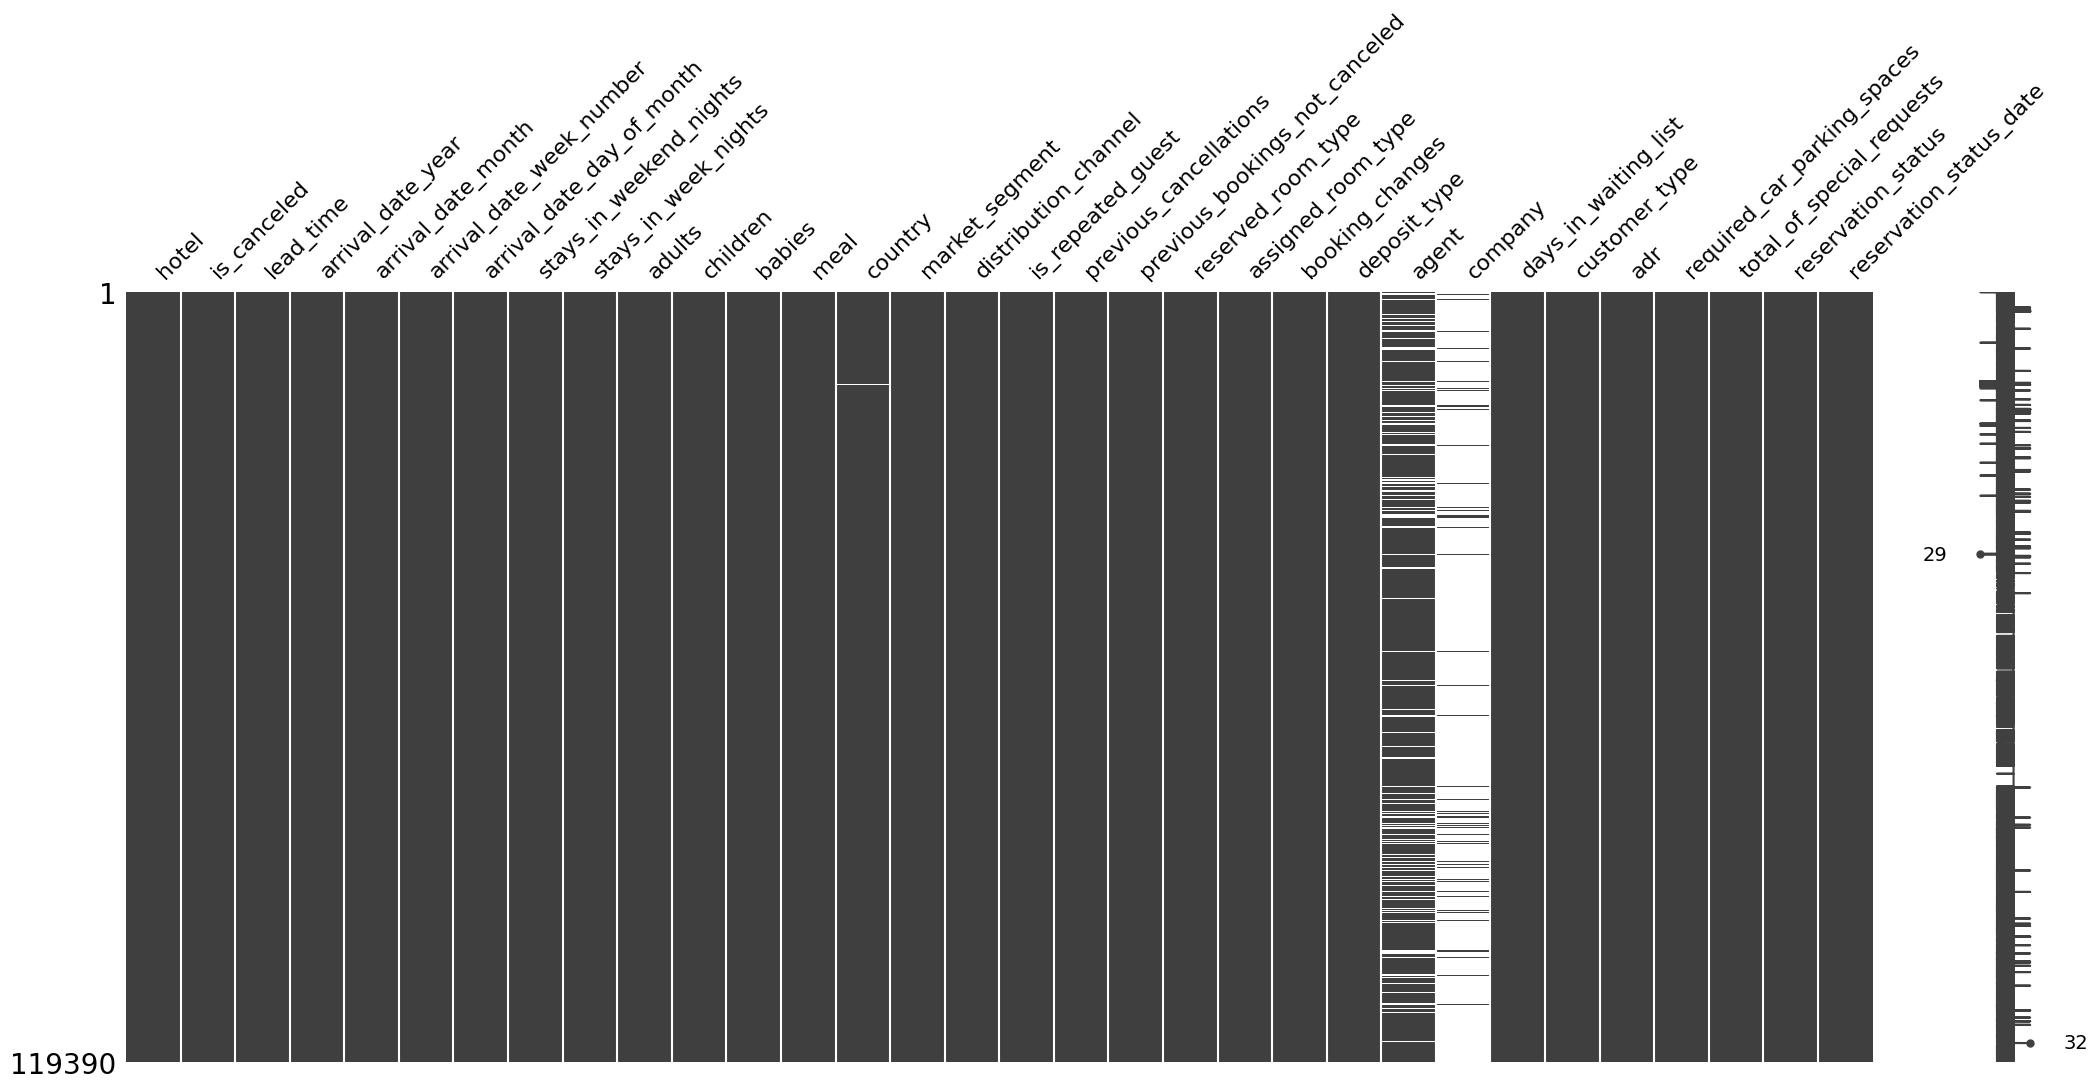

In [8]:
## To check the missing values
msno.matrix(df)

<Axes: >

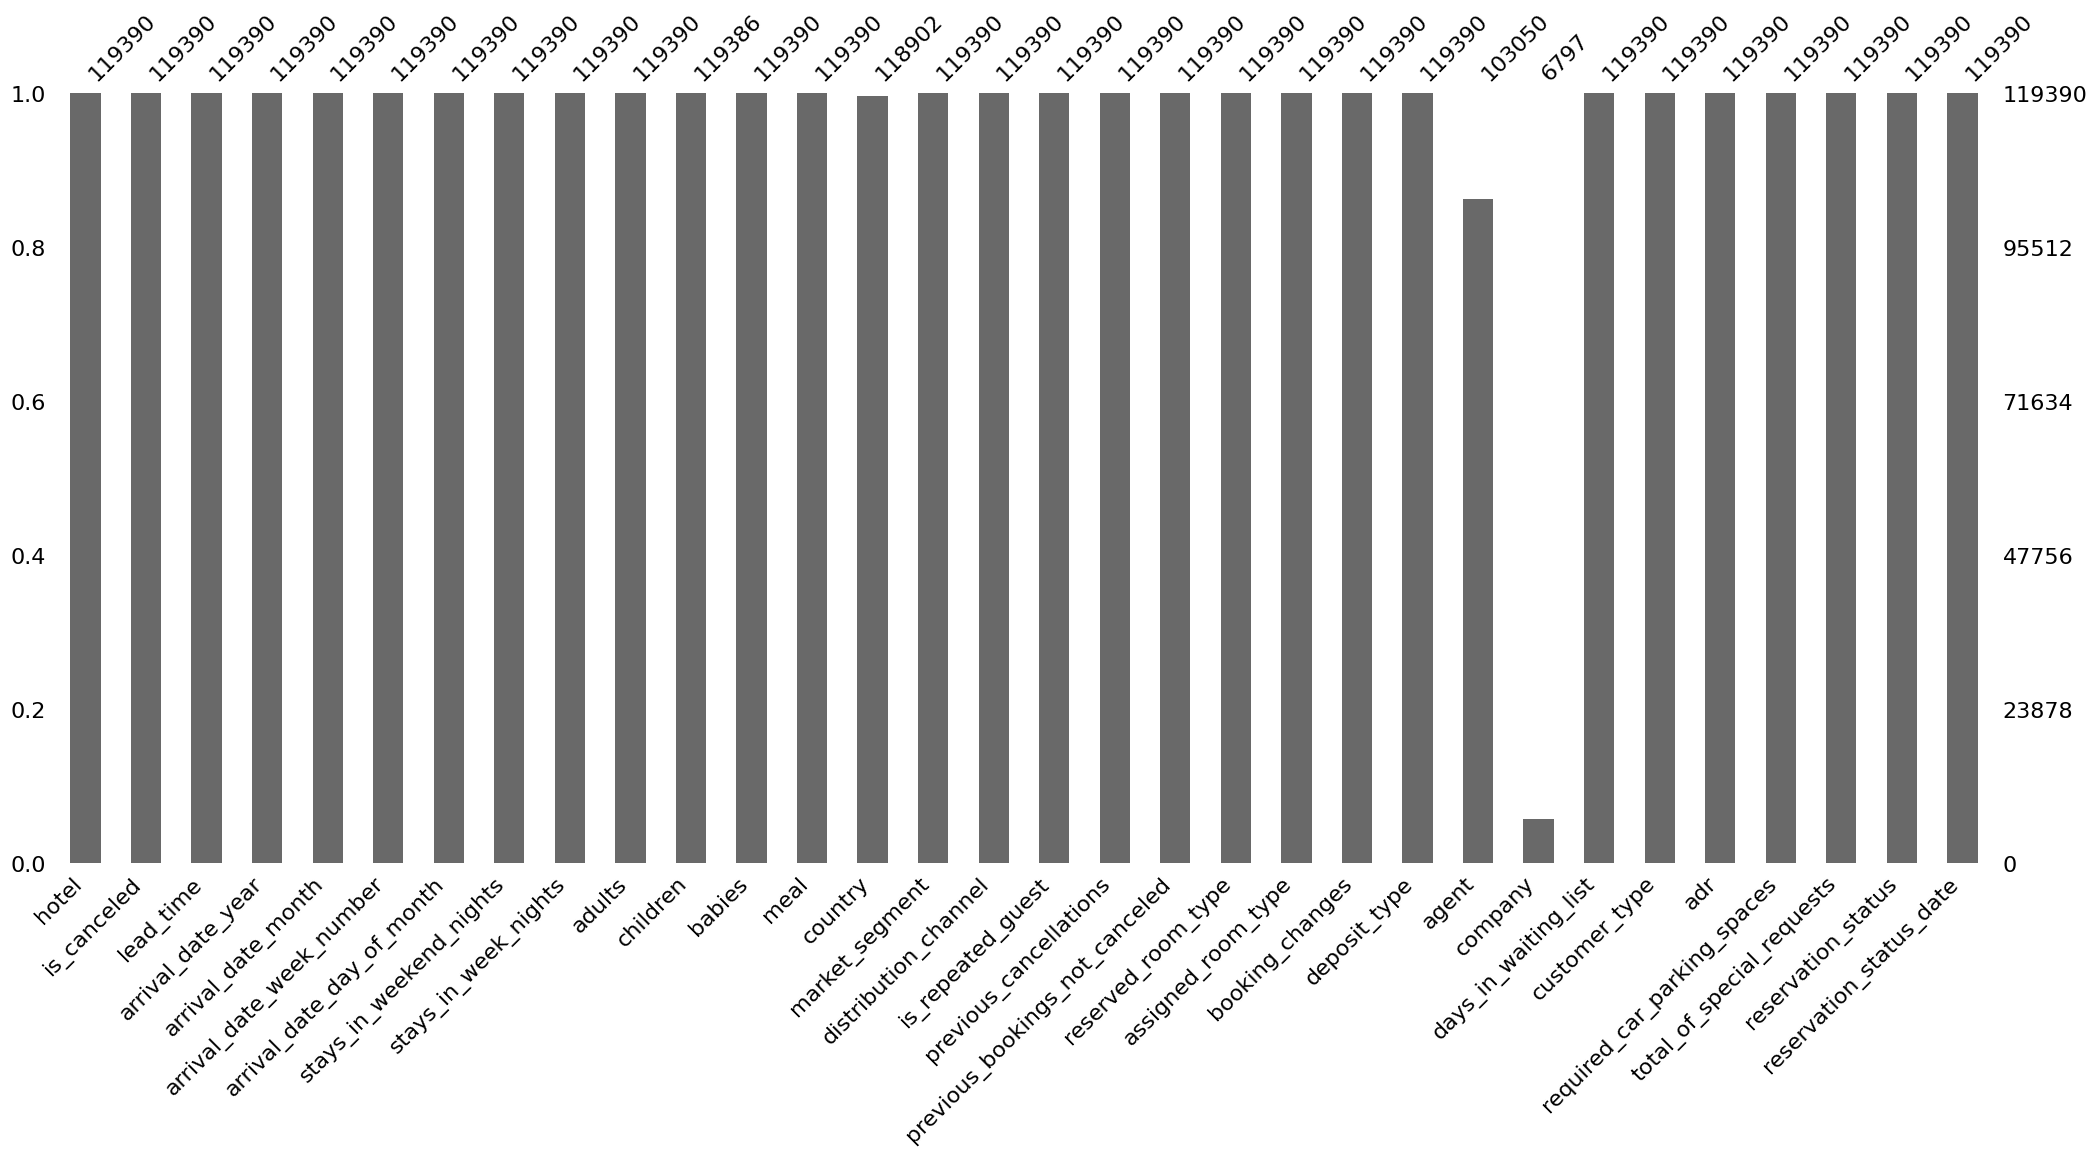

In [9]:
## How many values are present per column
msno.bar(df)

<Axes: >

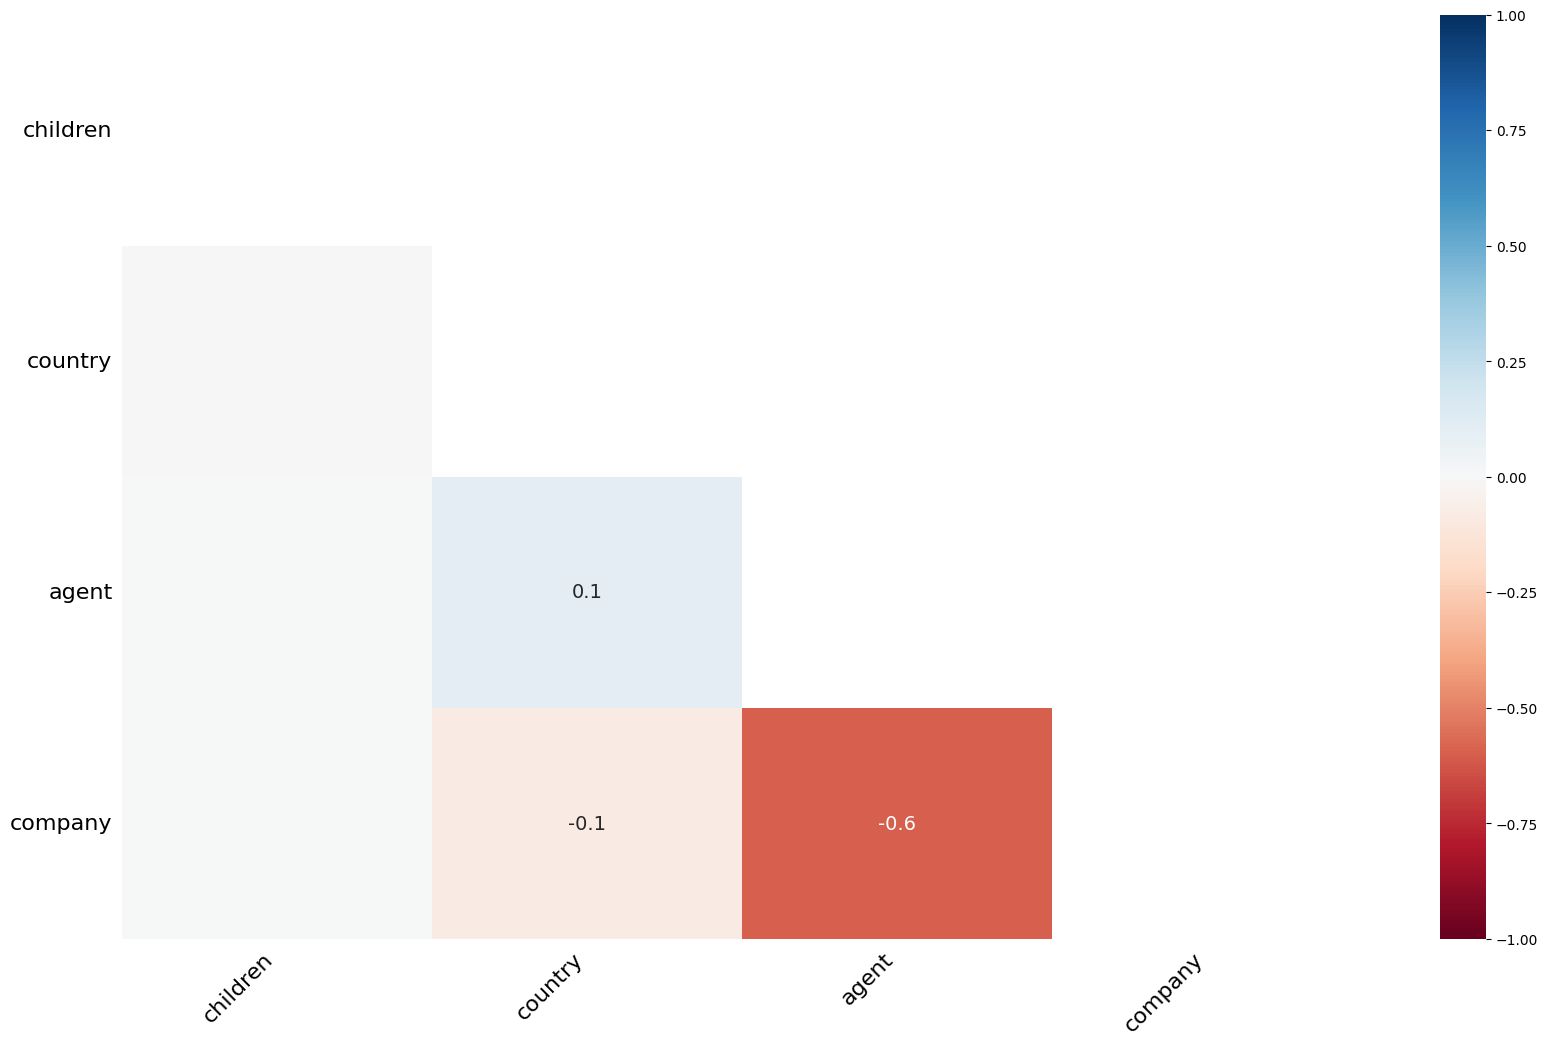

In [10]:
# How strongly two or more columns (with missing values) are related
msno.heatmap(df)
#A -0.6 correlation means a moderately strong inverse relationship between company and agent.

In [11]:
# The NaN values are changed to "Unknown". We don't want to delete the columns / rows because we want to preserve all the information.
# Since the three columns "country", "agent" and "company" are categorical, we replace null values with "Unknown"
categorical_cols = ['country', 'agent', 'company']
df[categorical_cols] = df[categorical_cols].fillna('Unknown')
# There are 4 missing values for children we replace them with 0
df['children'] = df['children'].fillna(0)
#Verifying if still null values are present
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [12]:
#Check which columns are categorical and which are numeric
# Get numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Get categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("No. of numeric columns: ", len(numeric_cols))
print("-------------------")
print("Categorical columns:", categorical_cols)
print("No. of numeric columns: ", len(categorical_cols))

Numeric columns: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
No. of numeric columns:  18
-------------------
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'reservation_status', 'reservation_status_date']
No. of numeric columns:  14


<h1>Data Preprocessing</h1>

In [13]:
# Removing unuseful columns
# 1. is_cancelled -> Outcome or post-event attribute; do not use to form clusters (allowed only for post-hoc profiling).
# 2. reservation_status -> Outcome or post-event attribute; do not use to form clusters (allowed only for post-hoc profiling).
# 3. reservation_status_date -> Outcome or post-event attribute; do not use to form clusters (allowed only for post-hoc profiling).

# These are variables that are known only after the event has already happened.
# Why?
# When a customer makes a booking, the hotel does not yet know whether the booking will be canceled. The cancellation happens later.

# These should NOT be used for clustering, but you should keep them to analyze the clusters after.

#Separate dataset for preserving the posthoc variables/columns
posthoc = df[['is_canceled', 'reservation_status', 'reservation_status_date', "adr"]]
posthoc.head()

# adr is excluded and put in posthoc. Although it is not post-event, It is used for business interpretation in this case.

# Later in business interpretation, we can do like,
# some cluster belong to low price bookings, some medium and some expensive bookings. 

,is_canceled,reservation_status,reservation_status_date,adr
0,0,Check-Out,2015-07-01,0.0
1,0,Check-Out,2015-07-01,0.0
2,0,Check-Out,2015-07-02,75.0
3,0,Check-Out,2015-07-02,75.0
4,0,Check-Out,2015-07-03,98.0


In [14]:
# We remove the post-hoc variables
# We remove agent and company (These behave like IDs or identifiers, which are bad for clustering.)
# We store the resulting data in df_cluster, We are going to use df_cluster dataset for implementing the clusterings

# assigned_room_type -> It is decided by the hotel after booking, it may differ from the reserved room, it leaks operational decisions


# arrival_date_month -> captures seasonality, which does influence behavior, so we only (This is the only temporal variable preserved).

# arrival_date_year ->The goal is customer segmentation, not temporal trend analysis (yearly trends/ yearly growth, etc.)
# arrival_date_day_of_month ->day of the month rarely reflects meaningful booking behavior.
# arrival_date_week_number -> It already encodes the same seasonal information as month.

drop_cols = [
    "is_canceled",
    "reservation_status",
    "reservation_status_date",
    "adr",
    "agent",
    "company",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "assigned_room_type"
]

df_cluster = df.drop(columns=drop_cols)

In [15]:
# Adding two new extra features (total_guests and stay_length
# total_guests = adults + children + babies 
# stay_length = stays_in_week_nights + stays_in_weekend_nights

# total_guests -> This captures group size, which affects booking behavior (1–2 couples / solo travelers, 3–4 families, 5+ group travelers).
# stay_length -> (This captures trip duration (For example, 1–2 nights short business trips, 3–4 nights weekend leisure time, 7+ nights vacations))

df_cluster["total_guests"] = df_cluster["adults"] + df_cluster["children"] + df_cluster["babies"]

df_cluster["stay_length"] = (
    df_cluster["stays_in_week_nights"] +
    df_cluster["stays_in_weekend_nights"]
)

In [16]:
df_cluster.head()

,hotel,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,required_car_parking_spaces,total_of_special_requests,total_guests,stay_length
0,Resort Hotel,342,July,0,0,2,0.0,0,BB,PRT,...,0,C,3,No Deposit,0,Transient,0,0,2.0,0
1,Resort Hotel,737,July,0,0,2,0.0,0,BB,PRT,...,0,C,4,No Deposit,0,Transient,0,0,2.0,0
2,Resort Hotel,7,July,0,1,1,0.0,0,BB,GBR,...,0,A,0,No Deposit,0,Transient,0,0,1.0,1
3,Resort Hotel,13,July,0,1,1,0.0,0,BB,GBR,...,0,A,0,No Deposit,0,Transient,0,0,1.0,1
4,Resort Hotel,14,July,0,2,2,0.0,0,BB,GBR,...,0,A,0,No Deposit,0,Transient,0,1,2.0,2


In [17]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   lead_time                       119390 non-null  int64  
 2   arrival_date_month              119390 non-null  object 
 3   stays_in_weekend_nights         119390 non-null  int64  
 4   stays_in_week_nights            119390 non-null  int64  
 5   adults                          119390 non-null  int64  
 6   children                        119390 non-null  float64
 7   babies                          119390 non-null  int64  
 8   meal                            119390 non-null  object 
 9   country                         119390 non-null  object 
 10  market_segment                  119390 non-null  object 
 11  distribution_channel            119390 non-null  object 
 12  is_repeated_gues

In [18]:
df_cluster.describe()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,total_guests,stay_length
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,2.321149,0.062518,0.571363,1.968239,3.427900
std,106.863097,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,17.594721,0.245291,0.792798,0.722394,2.557439
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000
50%,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000
75%,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,4.000000
max,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,8.000000,5.000000,55.000000,69.000000


In [19]:
#Check which columns are categorical and which are numeric
# Get numeric columns
numeric_cols = df_cluster.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Get categorical columns
categorical_cols = df_cluster.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("No. of numeric columns: ", len(numeric_cols))
print("-------------------")
print("Categorical columns:", categorical_cols)
print("No. of numeric columns: ", len(categorical_cols))

Numeric columns: ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'stay_length']
No. of numeric columns:  15
-------------------
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']
No. of numeric columns:  9


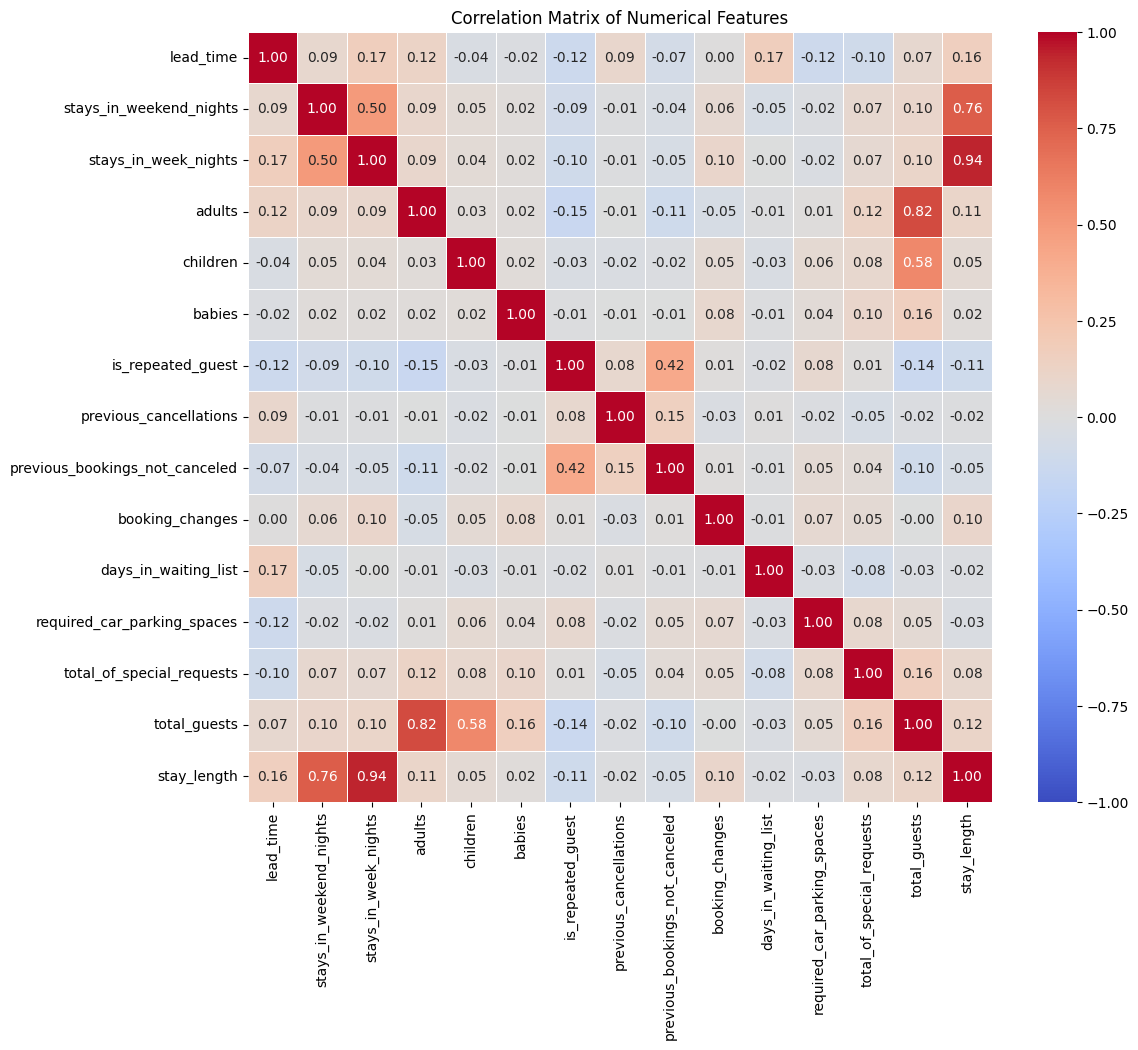

In [20]:
df_numeric = df_cluster[numeric_cols]

corr_matrix = df_numeric.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

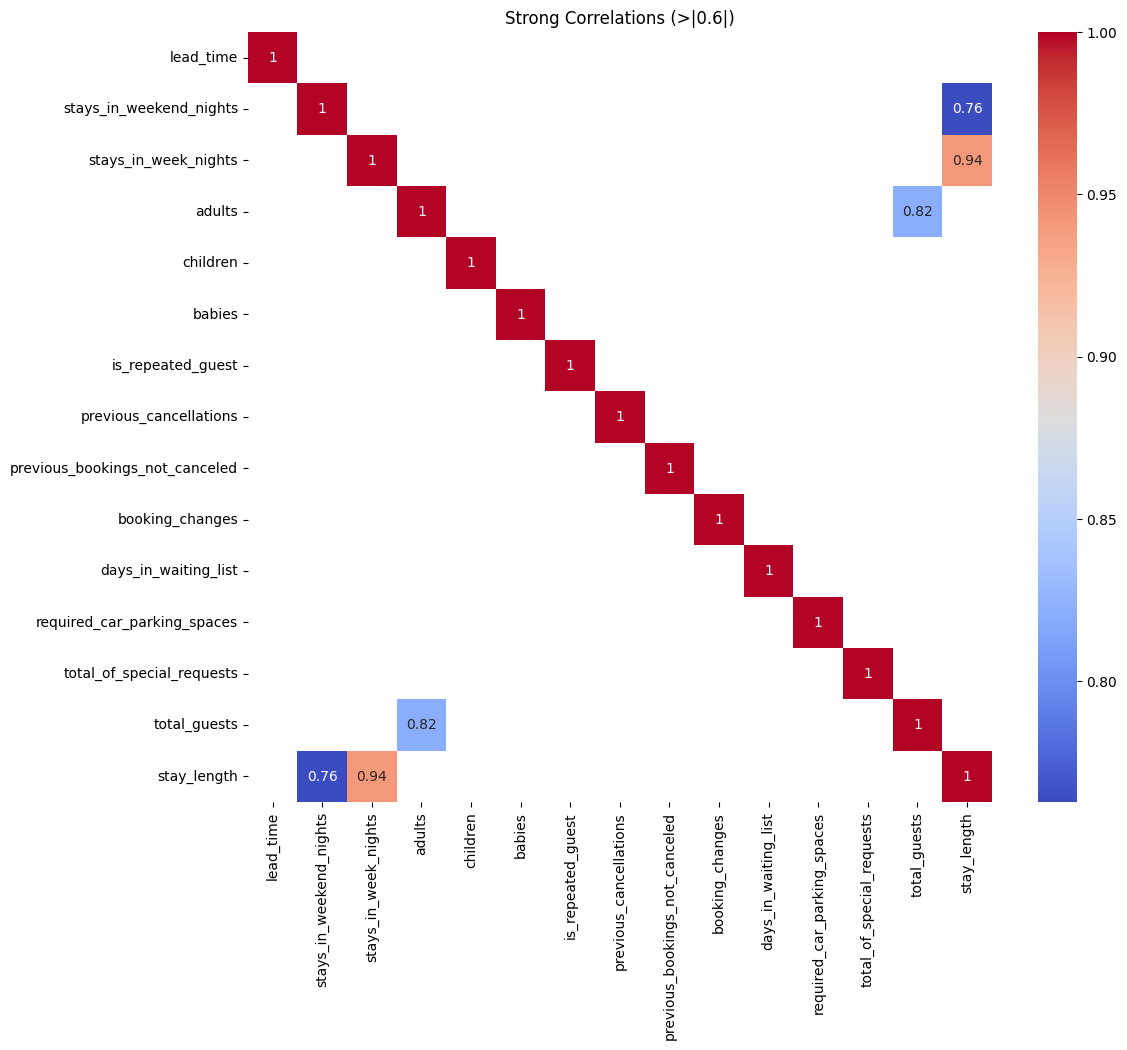

In [21]:
strong_corr = corr_matrix[(corr_matrix > 0.6) | (corr_matrix < -0.6)]

plt.figure(figsize=(12,10))
sns.heatmap(strong_corr, cmap="coolwarm", annot=True)
plt.title("Strong Correlations (>|0.6|)")
plt.show()

In [22]:
# --- Numeric columns: min, max, mean ---
print("Numeric Features Summary:\n")
numeric_summary = df_cluster[numeric_cols].agg(['min', 'max', 'mean', 'std'])
print(numeric_summary)
print("\n-------------------------\n")

# --- Categorical columns: number of unique categories ---
print("Categorical Features Summary:\n")
for col in categorical_cols:
    n_unique = df_cluster[col].nunique()
    print(f"{col}: {n_unique} categories")

Numeric Features Summary:

       lead_time  stays_in_weekend_nights  stays_in_week_nights     adults  \
min     0.000000                 0.000000              0.000000   0.000000   
max   737.000000                19.000000             50.000000  55.000000   
mean  104.011416                 0.927599              2.500302   1.856403   
std   106.863097                 0.998613              1.908286   0.579261   

       children     babies  is_repeated_guest  previous_cancellations  \
min    0.000000   0.000000           0.000000                0.000000   
max   10.000000  10.000000           1.000000               26.000000   
mean   0.103886   0.007949           0.031912                0.087118   
std    0.398555   0.097436           0.175767                0.844336   

      previous_bookings_not_canceled  booking_changes  days_in_waiting_list  \
min                         0.000000         0.000000              0.000000   
max                        72.000000        21.000000     

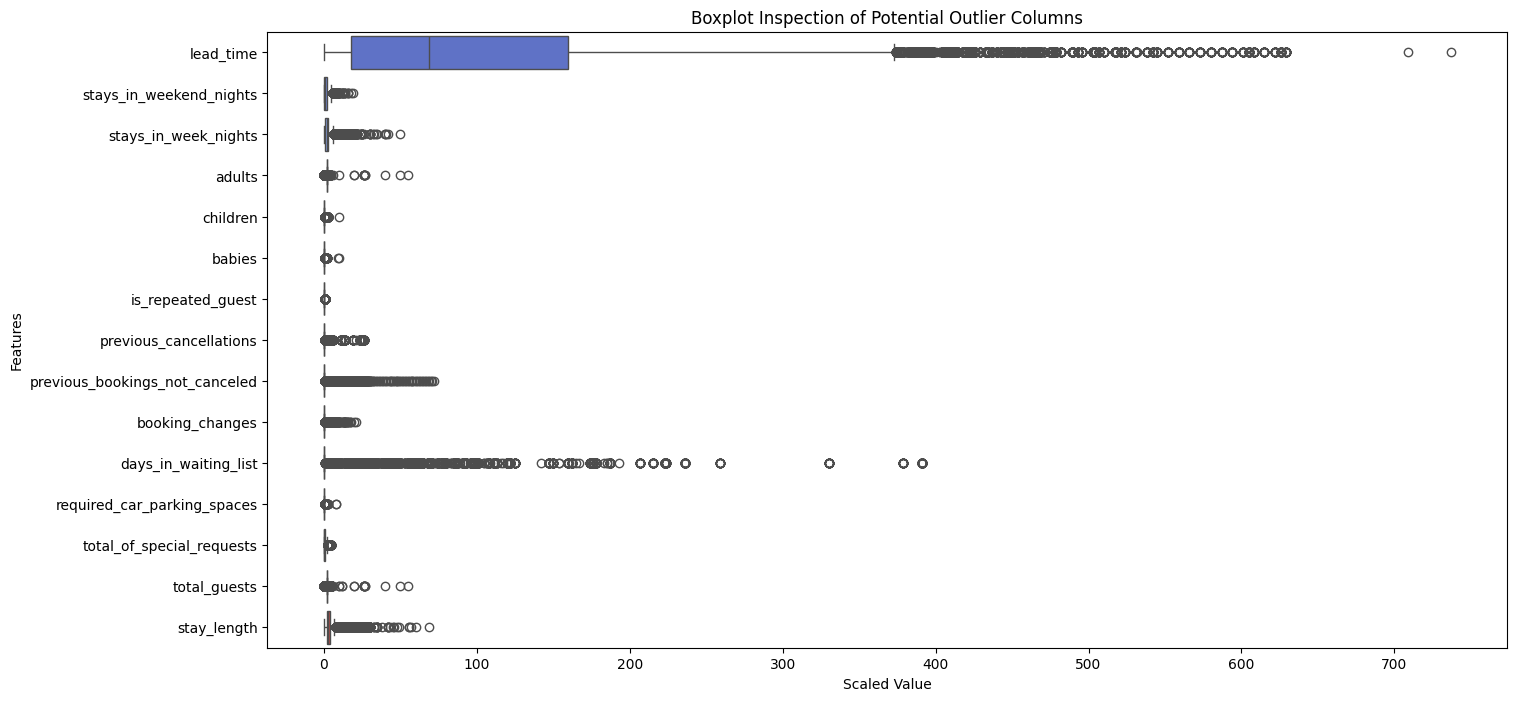

In [23]:
# Boxplot to find if there are outliers
plt.figure(figsize=(16, 8))

sns.boxplot(data=df_cluster[numeric_cols], orient='h', palette='coolwarm')

plt.title("Boxplot Inspection of Potential Outlier Columns")
plt.xlabel("Scaled Value")
plt.ylabel("Features")
plt.show()

# Below we can see some outliers

In [24]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] < lower) | (df[column] > upper)]

for col in numeric_cols:
    outliers = detect_outliers_iqr(df_cluster, col)
    print(col, len(outliers))

#Very high counts:
#---------
# adults -> 29,710 outliers
# total_guests -> 37,339 outliers
# booking_changes -> 18,076 outliers

# Moderate counts:
#---------
# lead_time -> 3,005 outliers
# stays_in_week_nights -> 3,354
# days_in_waiting_list -> 3,698

# Small counts:
#---------
#babies -> 917
#stays_in_weekend_nights -> 265

lead_time 3005
stays_in_weekend_nights 265
stays_in_week_nights 3354
adults 29710
children 8590
babies 917
is_repeated_guest 3810
previous_cancellations 6484
previous_bookings_not_canceled 3620
booking_changes 18076
days_in_waiting_list 3698
required_car_parking_spaces 7416
total_of_special_requests 2877
total_guests 37339
stay_length 5257


In [25]:
# AS PER THE SUGGESTION IN THE ASSIGNMENT
# ----------------------------------------
# High-cardinality categorical variables: unless justified, handle high-cardinality fields by dropping them,
# grouping rare categories into “Other”, and/or applying a minimum-frequency threshold prior to one-hot
# encoding.

# From above, we can see that country is a high cardinality feature
# ---------------------------------------------------------------------

# -------------------------
#  Define numeric and categorical columns
# -------------------------
numeric_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 
                'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
                'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 
                'total_of_special_requests', 'total_guests', 'stay_length']

categorical_cols = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
                    'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']

# -------------------------
# Custom transformer for high-cardinality categorical columns
# -------------------------
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Replace rare categories with 'Other' based on a minimum frequency threshold.
    """
    def __init__(self, threshold=0.01):  # threshold: min fraction of occurrences
        self.threshold = threshold
        self.frequent_categories_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            counts = X[col].value_counts(normalize=True)
            self.frequent_categories_[col] = counts[counts >= self.threshold].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].apply(lambda x: x if x in self.frequent_categories_[col] else 'Other')
        return X

    # This method is useful while inspecting preprocessed data later
    def get_feature_names_out(self, input_features=None):
        return input_features

# -------------------------
# Define transformers
# -------------------------
# Numeric transformer: scale features
numeric_transformer = StandardScaler()

# Categorical transformer: group rare categories + one-hot encode
categorical_transformer = Pipeline(steps=[
    ('rare_grouper', RareCategoryGrouper(threshold=0.01)),  # adjust threshold as needed
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# -------------------------
# Combine into ColumnTransformer
# -------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# -------------------------
# Build full pipeline
# -------------------------
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# -------------------------
# Fit and transform the data
# -------------------------
df_preprocessed = pipeline.fit_transform(df_cluster)

print("Preprocessing complete!")
print("Final preprocessed dataset shape:", df_preprocessed.shape)

Preprocessing complete!
Final preprocessed dataset shape: (119390, 71)


In [26]:
# Just to inspect the preprocessed data

# Get feature names from the pipeline
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
# Convert to DataFrame
df_preprocessed = pd.DataFrame(df_preprocessed, columns=feature_names)

df_preprocessed.head()

# Numerical variables were standardized using StandardScaler, resulting in features with mean approximately zero and unit variance. 
# Categorical variables were encoded using one-hot encoding after grouping rare categories using a minimum frequency threshold. 
# The final dataset contains 71 features. One-hot encoded variables take binary values (0 or 1), 
# while standardized numerical features may take positive or negative values depending on their distance from the mean.

,num__lead_time,num__stays_in_weekend_nights,num__stays_in_week_nights,num__adults,num__children,num__babies,num__is_repeated_guest,num__previous_cancellations,num__previous_bookings_not_canceled,num__booking_changes,...,cat__reserved_room_type_F,cat__reserved_room_type_G,cat__reserved_room_type_Other,cat__deposit_type_No Deposit,cat__deposit_type_Non Refund,cat__deposit_type_Other,cat__customer_type_Contract,cat__customer_type_Other,cat__customer_type_Transient,cat__customer_type_Transient-Party
0,2.227051,-0.92889,-1.310240,0.247897,-0.260659,-0.081579,-0.18156,-0.10318,-0.091555,4.260101,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,5.923385,-0.92889,-1.310240,0.247897,-0.260659,-0.081579,-0.18156,-0.10318,-0.091555,5.793131,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.907814,-0.92889,-0.786207,-1.478447,-0.260659,-0.081579,-0.18156,-0.10318,-0.091555,-0.338990,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.851667,-0.92889,-0.786207,-1.478447,-0.260659,-0.081579,-0.18156,-0.10318,-0.091555,-0.338990,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.842309,-0.92889,-0.262174,0.247897,-0.260659,-0.081579,-0.18156,-0.10318,-0.091555,-0.338990,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
summary_stats = df_preprocessed.agg(['min', 'max', 'mean'])
summary_stats

,num__lead_time,num__stays_in_weekend_nights,num__stays_in_week_nights,num__adults,num__children,num__babies,num__is_repeated_guest,num__previous_cancellations,num__previous_bookings_not_canceled,num__booking_changes,...,cat__reserved_room_type_F,cat__reserved_room_type_G,cat__reserved_room_type_Other,cat__deposit_type_No Deposit,cat__deposit_type_Non Refund,cat__deposit_type_Other,cat__customer_type_Contract,cat__customer_type_Other,cat__customer_type_Transient,cat__customer_type_Transient-Party
min,-9.733187e-01,-9.288904e-01,-1.310240e+00,-3.204792e+00,-2.606586e-01,-8.157926e-02,-1.815604e-01,-1.031795e-01,-9.155477e-02,-3.389899e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,5.923385e+00,1.809757e+01,2.489140e+01,9.174417e+01,2.483007e+01,1.025501e+02,5.507809e+00,3.069036e+01,4.799081e+01,3.185465e+01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
mean,6.094277e-17,1.197430e-16,-2.761469e-17,3.237585e-17,-3.999369e-17,2.047296e-17,9.522308e-18,-3.142362e-17,2.047296e-17,3.428031e-17,...,0.024265,0.017539,0.022355,0.876464,0.122179,0.001357,0.03414,0.004833,0.750591,0.210436


In [28]:
# df_preprocessed.head()

In [29]:
# Optional PCA for dimensionality reduction before K-Means
# -------------------------
pca_before_kmeans = PCA(n_components=20, random_state=42)
X_reduced = pca_before_kmeans.fit_transform(df_preprocessed)

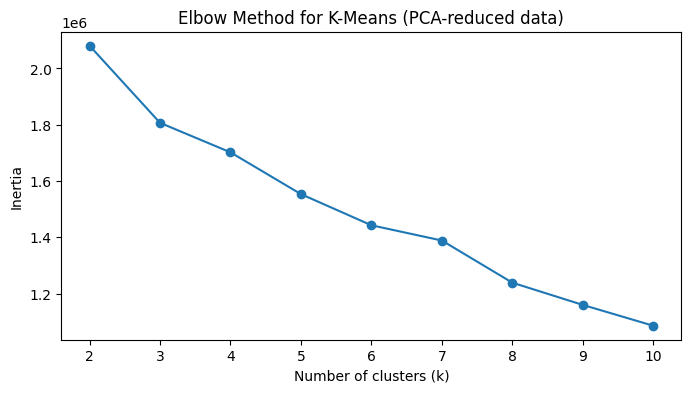

In [30]:
# -------------------------
# Step 1: Determine a reasonable number of clusters (Elbow Method)
# -------------------------
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_reduced)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means (PCA-reduced data)")
plt.show()

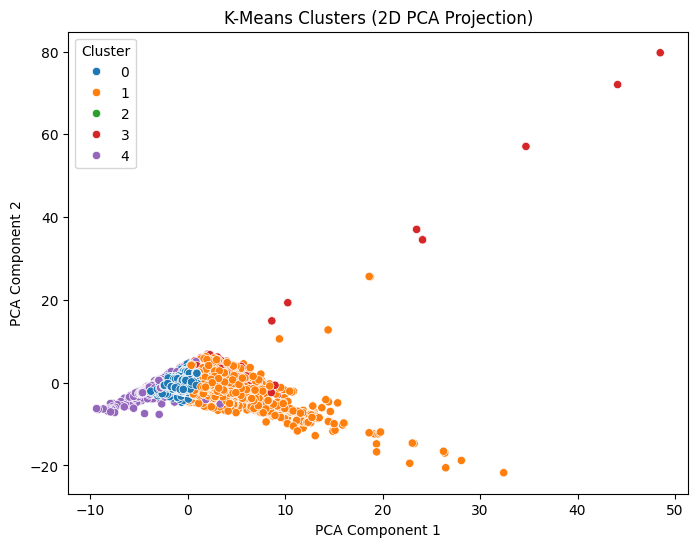

In [31]:
# -------------------------
# Fit K-Means with chosen k
# -------------------------
# Suppose elbow suggests k=8
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(X_reduced)

# -------------------------
# Add cluster labels to original DataFrame
# -------------------------
df_clustered = df_cluster.copy()
df_clustered['cluster'] = cluster_labels

# -------------------------
# Visualize clusters using PCA to 2D
# -------------------------
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(df_preprocessed)  # still use full preprocessed data for visualization

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=cluster_labels, palette='tab10')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (2D PCA Projection)")
plt.legend(title='Cluster')
plt.show()

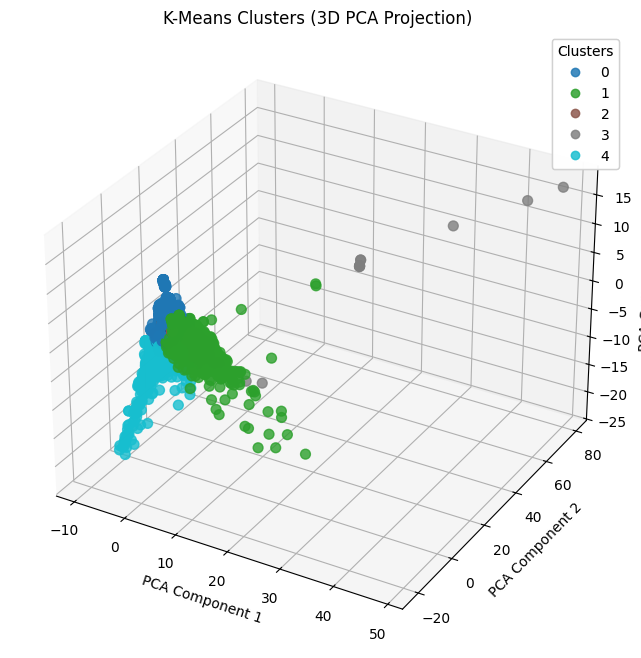

In [32]:
# -------------------------
# Reduce to 3D for visualization
# -------------------------
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(df_preprocessed)

# -------------------------
#  3D scatter plot
# -------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter with clusters
scatter = ax.scatter(
    X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
    c=cluster_labels, cmap='tab10', s=50, alpha=0.8
)

# Labels and title
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('K-Means Clusters (3D PCA Projection)')

# Legend
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.show()

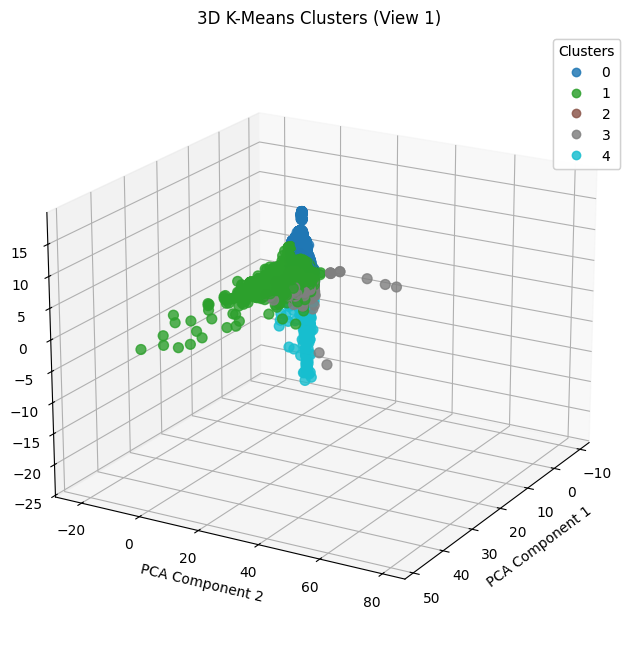

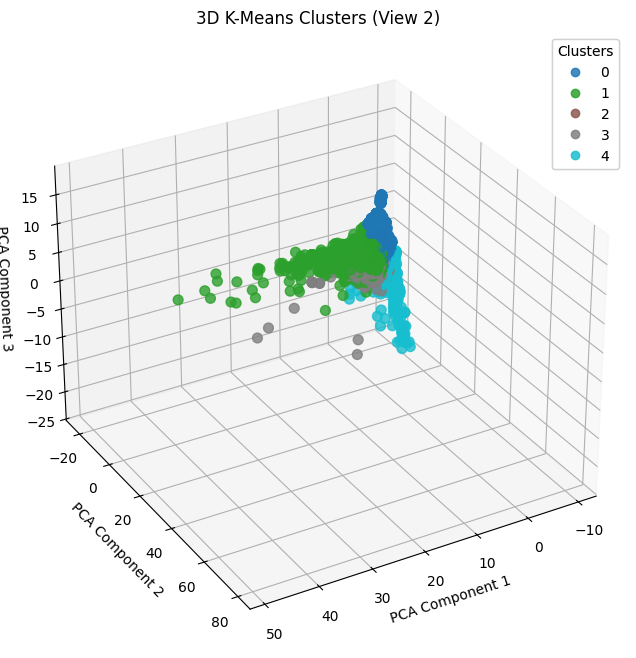

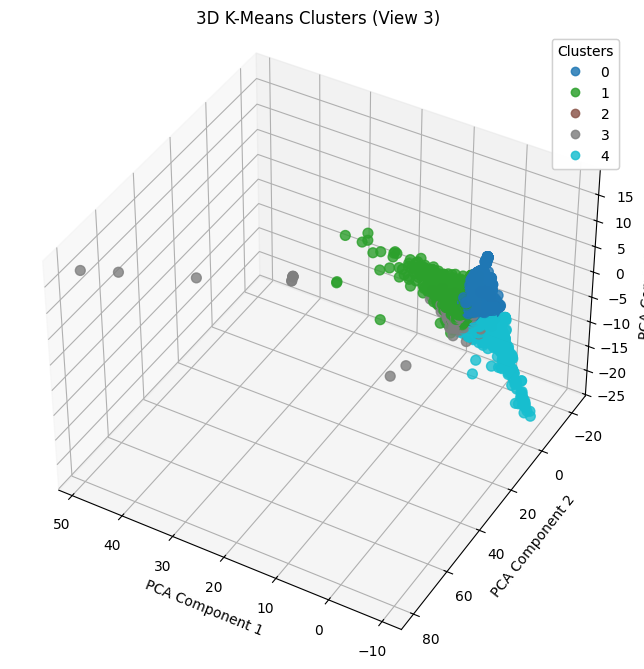

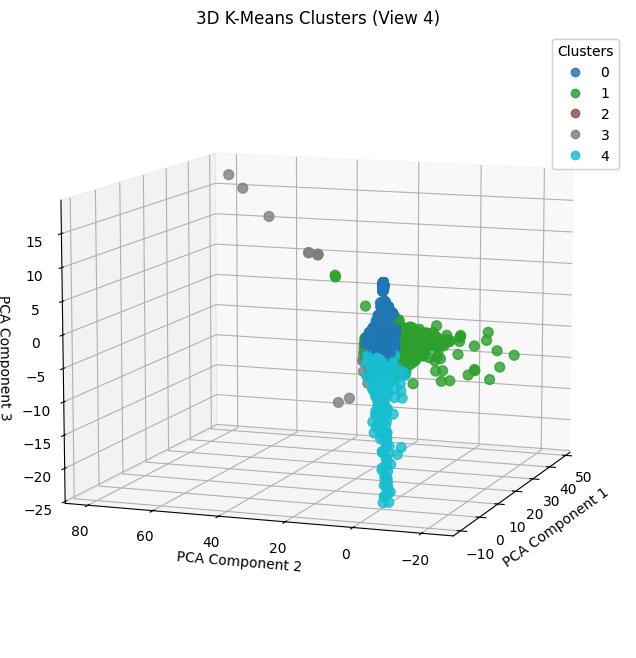

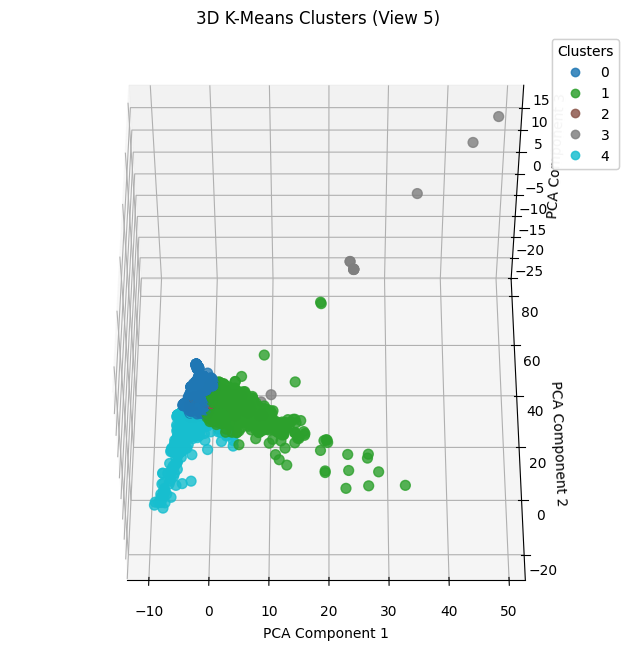

In [33]:
# Reduce to 3D
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(df_preprocessed)

# Define some angles: (elevation, azimuth)
angles = [(20, 30), (30, 60), (40, 120), (10, 200), (50, 270)]

for i, (elev, azim) in enumerate(angles):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
        c=cluster_labels, cmap='tab10', s=50, alpha=0.8
    )

    # Set labels and title
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.set_zlabel('PCA Component 3')
    ax.set_title(f'3D K-Means Clusters (View {i+1})')

    # Set the view angle
    ax.view_init(elev=elev, azim=azim)

    # Legend
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend1)

    plt.show()

   k       inertia  silhouette  calinski_harabasz  davies_bouldin
0  4  1.701934e+06    0.184050        1179.745514        1.460388
1  5  1.553399e+06    0.213316        1261.762352        1.391013
2  6  1.442699e+06    0.133769        1415.174650        1.517093
3  7  1.388449e+06    0.128580        1298.435515        1.524045
4  8  1.238616e+06    0.150221        1535.780237        1.413208
5  9  1.159557e+06    0.149170        1430.093343        1.328379


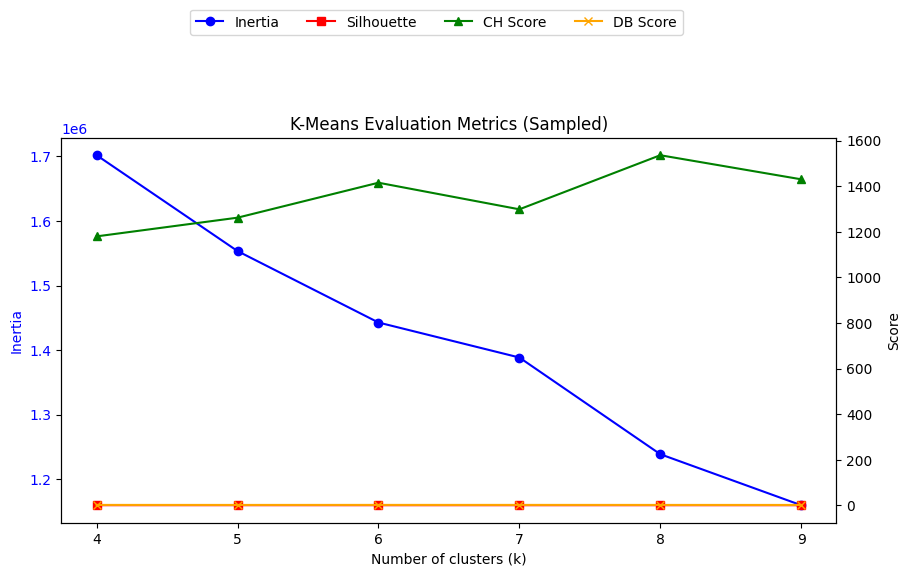

In [34]:
# -------------------------
# Use PCA-reduced data (from before)
# -------------------------
X_eval = X_reduced  # your 20-component PCA data

# -------------------------
# Parameters
# -------------------------
candidate_k = range(4, 10)  # k = 4 to 9
sample_size = min(15000, X_eval.shape[0])  # for sampled metrics
rng = np.random.default_rng(42)

# Store results
results = []

for k in candidate_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_eval)
    
    # Inertia is fast
    inertia = kmeans.inertia_
    
    # Sample for other metrics
    if X_eval.shape[0] > sample_size:
        idx = rng.choice(X_eval.shape[0], size=sample_size, replace=False)
        X_sample = X_eval[idx]
        labels_sample = labels[idx]
    else:
        X_sample = X_eval
        labels_sample = labels
    
    # Compute metrics
    silhouette = silhouette_score(X_sample, labels_sample)
    ch_score = calinski_harabasz_score(X_sample, labels_sample)
    db_score = davies_bouldin_score(X_sample, labels_sample)
    
    results.append({
        'k': k,
        'inertia': inertia,
        'silhouette': silhouette,
        'calinski_harabasz': ch_score,
        'davies_bouldin': db_score
    })

# Convert to DataFrame for easy inspection
df_metrics = pd.DataFrame(results)
print(df_metrics)

# Optional: visualize metrics
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(df_metrics['k'], df_metrics['inertia'], 'o-', color='blue', label='Inertia')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(df_metrics['k'], df_metrics['silhouette'], 's-', color='red', label='Silhouette')
ax2.plot(df_metrics['k'], df_metrics['calinski_harabasz'], '^-', color='green', label='CH Score')
ax2.plot(df_metrics['k'], df_metrics['davies_bouldin'], 'x-', color='orange', label='DB Score')
ax2.set_ylabel('Score', color='black')
ax2.tick_params(axis='y', labelcolor='black')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)
plt.title("K-Means Evaluation Metrics (Sampled)")
plt.show()


#Analysis:
#----------
# Inertia (Elbow)
# Still decreases with k.
# The “elbow” where the decrease slows seems to be around k=5–6.

# Silhouette
# Highest at k=5 (0.213) → clusters are tight and well-separated.
# Drops sharply after k=5 → over-clustering reduces cluster quality.

# Calinski-Harabasz (CH)
# Higher is better. Peaks at k=8 (1535.8) and k=6 (1415.2).

# Davies-Bouldin (DB)
# Lower is better. Best at k=9 (1.328) and next is k=5 (1.391).

# Overall, k=5 seems to be a strong choice based on silhouette and DB scores, with decent inertia and CH score.

In [35]:
# Cluster Profiling
# Group by cluster and calculate the mean for numeric features
cluster_profile = df_clustered.groupby('cluster')[numeric_cols].mean()

# Transpose it to make it easier to read (Features as rows, Clusters as columns)
cluster_profile_t = cluster_profile.T
print(cluster_profile_t)

cluster                                  0           1           2          3  \
lead_time                       102.203728  119.895928  229.703448  80.474649   
stays_in_weekend_nights           0.630193    1.910622    1.055172   1.159655   
stays_in_week_nights              1.870321    4.582675    2.813793   3.011866   
adults                            1.813536    2.038075    2.000000   2.326861   
children                          0.020350    0.369061    0.000000   0.223301   
babies                            0.000000    0.000000    0.000000   1.023732   
is_repeated_guest                 0.000000    0.001359    0.089655   0.012945   
previous_cancellations            0.057282    0.018591   21.979310   0.009709   
previous_bookings_not_canceled    0.016767    0.006650    0.075862   0.017260   
booking_changes                   0.169638    0.354725    0.006897   0.872708   
days_in_waiting_list              3.075910    0.358621    2.351724   0.031284   
required_car_parking_spaces 

cluster                                0         1         2         3  \
lead_time                      -0.153332  0.114431  1.776316 -0.482191   
stays_in_weekend_nights        -0.775025  1.694599  0.044654  0.246174   
stays_in_week_nights           -0.782930  1.679429  0.073583  0.253400   
adults                         -0.310503  0.405061  0.283722  1.325368   
children                       -0.746169  1.661463 -0.886670  0.655083   
babies                         -0.500000 -0.500000 -0.500000  2.000000   
is_repeated_guest              -0.565740 -0.562206 -0.332521 -0.532067   
previous_cancellations         -0.508778 -0.513206  1.999642 -0.514222   
previous_bookings_not_canceled -0.508008 -0.514611 -0.469441 -0.507686   
booking_changes                -0.555749  0.075231 -1.110556  1.841097   
days_in_waiting_list            1.485876 -0.657196  0.914725 -0.915361   
required_car_parking_spaces    -0.684148 -0.137686 -1.416370  1.151523   
total_of_special_requests      -0.4358

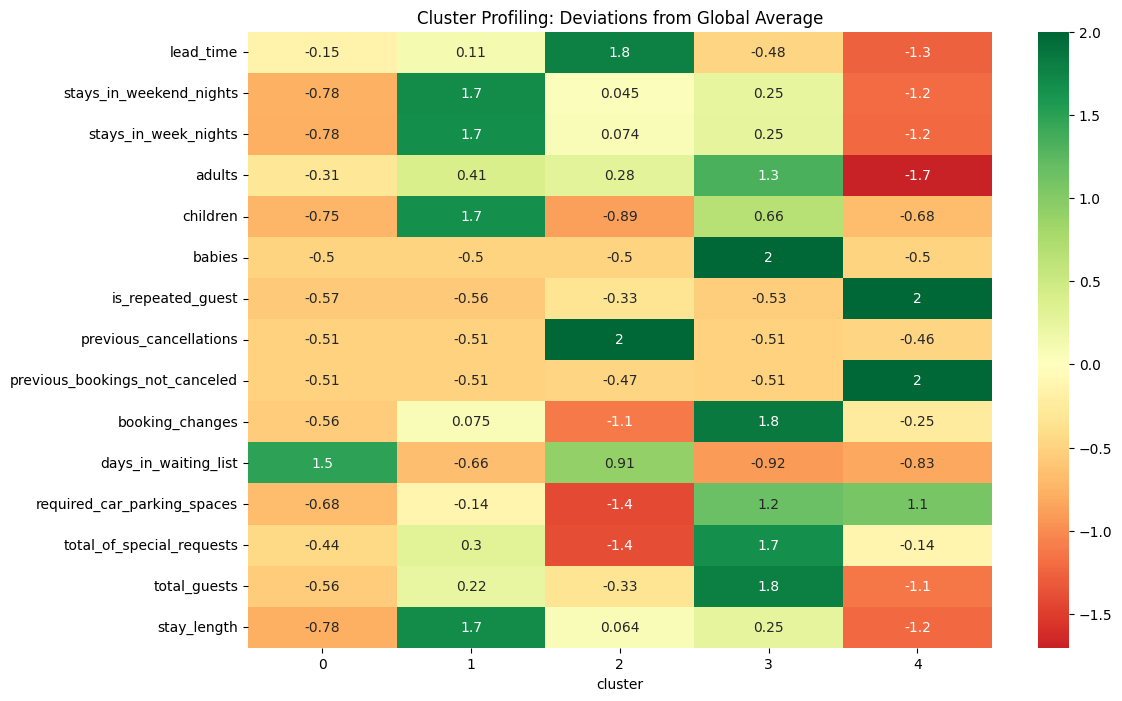

In [36]:
# Normalize the profile so we can compare different scales (e.g. lead_time vs adults)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

profile_scaled = scaler.fit_transform(cluster_profile)
profile_scaled_df = pd.DataFrame(profile_scaled, columns=numeric_cols, index=cluster_profile.index).T

print(profile_scaled_df)

plt.figure(figsize=(12, 8))
sns.heatmap(profile_scaled_df, annot=True, cmap='RdYlGn', center=0)
plt.title("Cluster Profiling: Deviations from Global Average")
plt.show()

In [37]:
top_10_countries = df_clustered['country'].value_counts().nlargest(10).index
print(top_10_countries)

Index(['PRT', 'GBR', 'FRA', 'ESP', 'DEU', 'ITA', 'IRL', 'BEL', 'BRA', 'NLD'], dtype='object', name='country')


In [38]:
df_clustered['country_top10'] = df_clustered['country'].apply(
    lambda x: x if x in top_10_countries else 'Other'
)

In [39]:
counts = pd.crosstab(df_clustered['cluster'], df_clustered['country_top10'])

percentages = counts.div(counts.sum(axis=1), axis=0) * 100

print("\n===== country (Top 10 + Other) =====")
print(percentages.round(2))


===== country (Top 10 + Other) =====
country_top10   BEL   BRA   DEU    ESP   FRA    GBR    IRL   ITA   NLD  Other  \
cluster                                                                         
0              1.93  1.72  6.43   7.27  8.91   7.66   1.81  3.40  1.73  15.34   
1              2.26  2.48  6.00   7.38  9.11  19.02   6.18  2.75  2.06  18.09   
2              9.66  0.00  0.00   0.00  0.69   0.00  16.55  0.00  0.00   0.00   
3              1.29  2.59  1.94  13.59  8.31   8.95   2.59  1.73  1.08  11.97   
4              0.42  0.37  0.63   2.36  1.99   2.52   0.71  1.05  0.52   3.83   

country_top10    PRT  
cluster               
0              43.79  
1              24.68  
2              73.10  
3              45.95  
4              85.59  


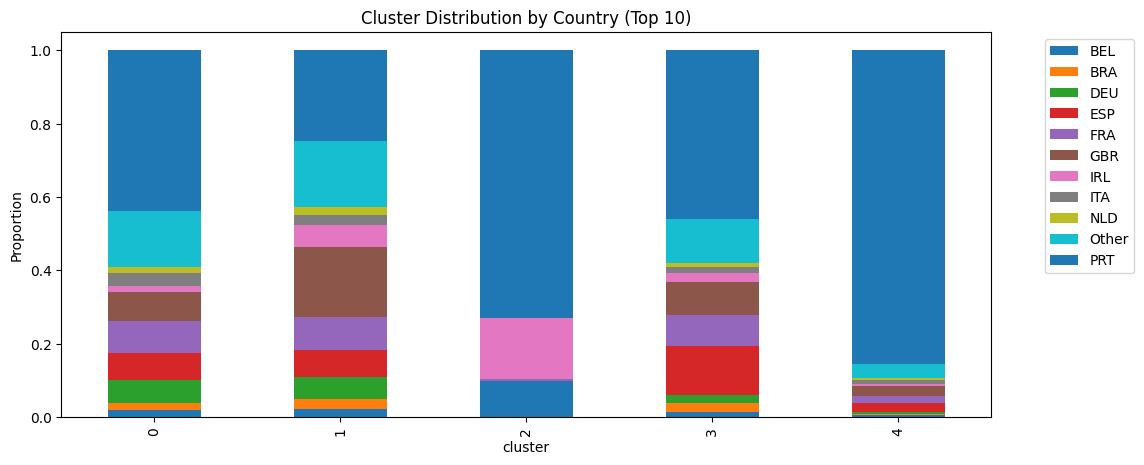

In [40]:
plt.figure(figsize=(12,5))

ct = pd.crosstab(
    df_clustered['cluster'],
    df_clustered['country_top10'],
    normalize='index'
)

ct.plot(kind='bar', stacked=True, ax=plt.gca())

plt.title("Cluster Distribution by Country (Top 10)")
plt.ylabel("Proportion")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

In [41]:
# Sort the countries by frequency (Better for visualization)
top_10 = df_clustered['country'].value_counts().nlargest(10).index.tolist()
ct = ct[top_10 + ['Other']]
#ct = ct[top_10_countries.tolist() + ['Other']]
#print(ct)

In [42]:
for col in categorical_cols:

    if col == 'country':
        top_10 = df_clustered['country'].value_counts().nlargest(10).index
        temp = df_clustered['country'].apply(lambda x: x if x in top_10 else 'Other')
        counts = pd.crosstab(df_clustered['cluster'], temp)
    else:
        counts = pd.crosstab(df_clustered['cluster'], df_clustered[col])

    percentages = counts.div(counts.sum(axis=1), axis=0) * 100

    print(f"\n===== {col} =====")
    print(percentages.round(2))


===== hotel =====
hotel    City Hotel  Resort Hotel
cluster                          
0             75.60         24.40
1             41.10         58.90
2              8.97         91.03
3             39.81         60.19
4             53.15         46.85

===== arrival_date_month =====
arrival_date_month  April  August  December  February  January   July  June  \
cluster                                                                       
0                    9.46    9.64      5.74      7.19     5.31   8.83  9.25   
1                    9.12   18.30      5.07      4.92     3.24  16.35  9.26   
2                    7.59    0.00      0.00      0.69     0.00  17.24  0.00   
3                    5.72   21.04      8.31      6.04     4.10  12.84  7.44   
4                    7.43    5.70      8.27     10.92    10.37   7.90  7.30   

arrival_date_month  March    May  November  October  September  
cluster                                                         
0                    8.58  

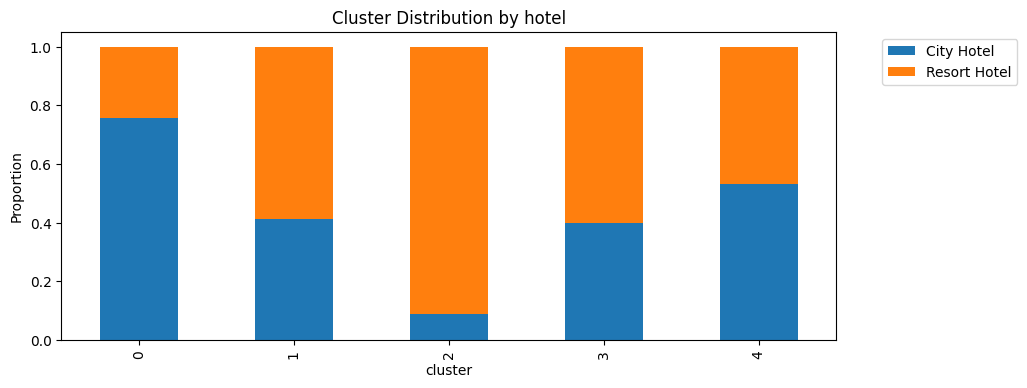

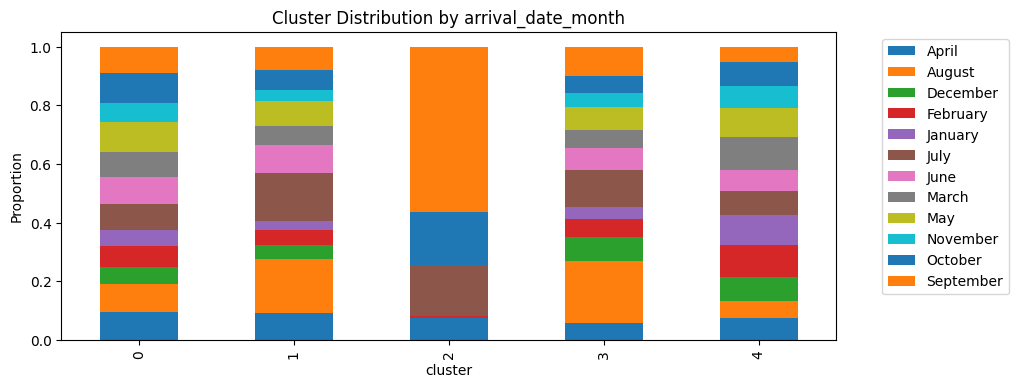

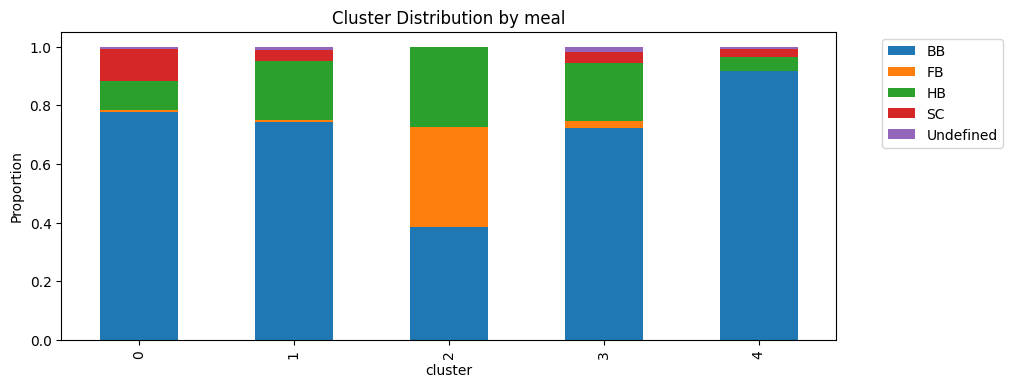

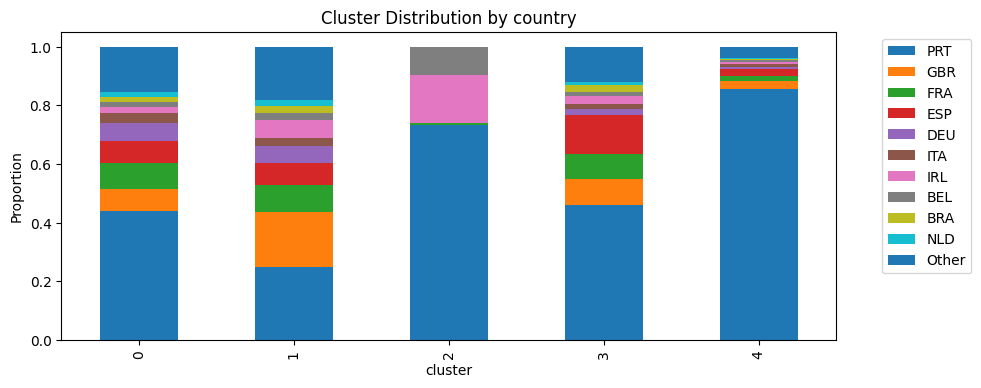

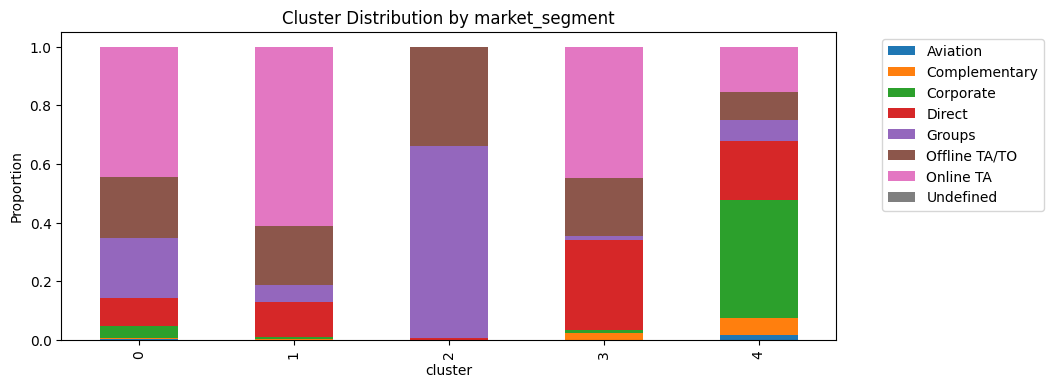

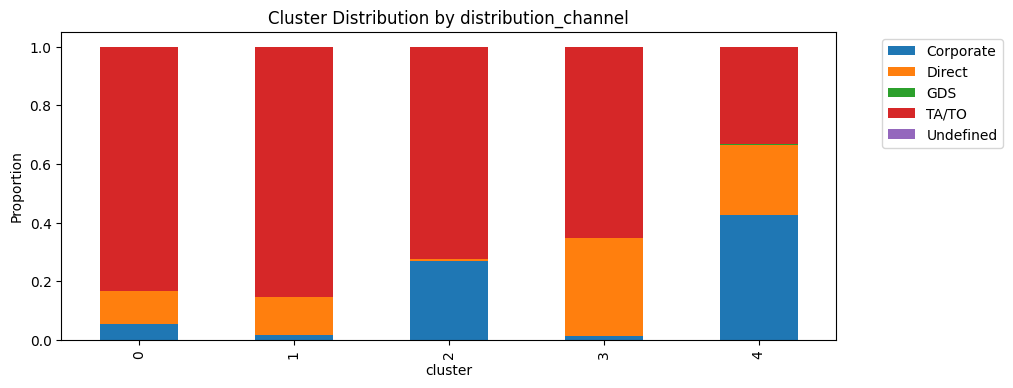

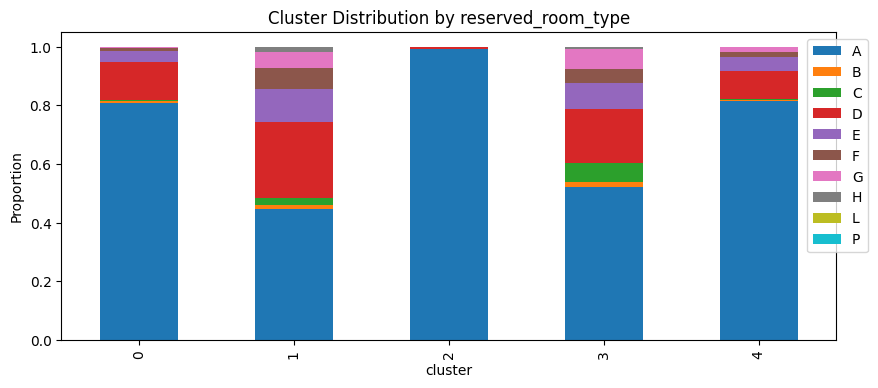

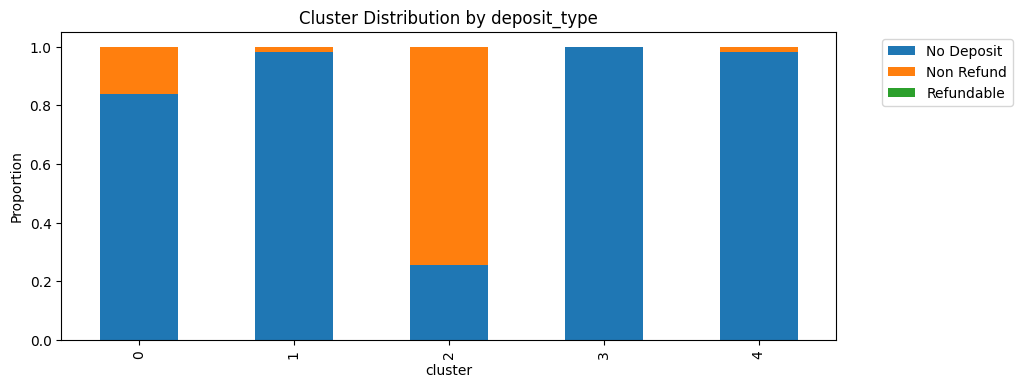

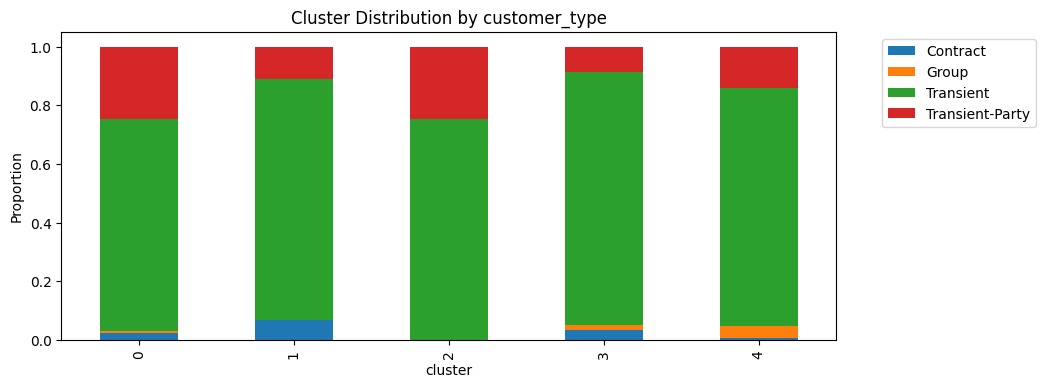

In [43]:
for col in categorical_cols:

    plt.figure(figsize=(10,4))

    if col == "country":
        top_10 = df_clustered['country'].value_counts().nlargest(10).index.tolist()
        
        temp_col = df_clustered['country'].apply(
            lambda x: x if x in top_10 else "Other"
        )
        
        ct = pd.crosstab(df_clustered['cluster'], temp_col, normalize='index')
        ct = ct[top_10 + ['Other']]

    else:
        ct = pd.crosstab(df_clustered['cluster'], df_clustered[col], normalize='index')

    ct.plot(kind='bar', stacked=True, ax=plt.gca())

    plt.title(f"Cluster Distribution by {col}")
    plt.ylabel("Proportion")
    plt.legend(bbox_to_anchor=(1.05,1))

    plt.show()

In [44]:
# Most common category per cluster
# Sometimes we want a quick interpretation.
# This helps write interpretations like:
# Cluster 0 represents City Hotel customers booking via Online Travel Agents with BB meal plans.

cluster_modes = df_clustered.groupby('cluster')[categorical_cols].agg(lambda x: x.mode()[0])

print(cluster_modes)

                hotel arrival_date_month meal country market_segment  \
cluster                                                                
0          City Hotel                May   BB     PRT      Online TA   
1        Resort Hotel             August   BB     PRT      Online TA   
2        Resort Hotel          September   BB     PRT         Groups   
3        Resort Hotel             August   BB     PRT      Online TA   
4          City Hotel              March   BB     PRT      Corporate   

        distribution_channel reserved_room_type deposit_type customer_type  
cluster                                                                     
0                      TA/TO                  A   No Deposit     Transient  
1                      TA/TO                  A   No Deposit     Transient  
2                      TA/TO                  A   Non Refund     Transient  
3                      TA/TO                  A   No Deposit     Transient  
4                  Corporate     

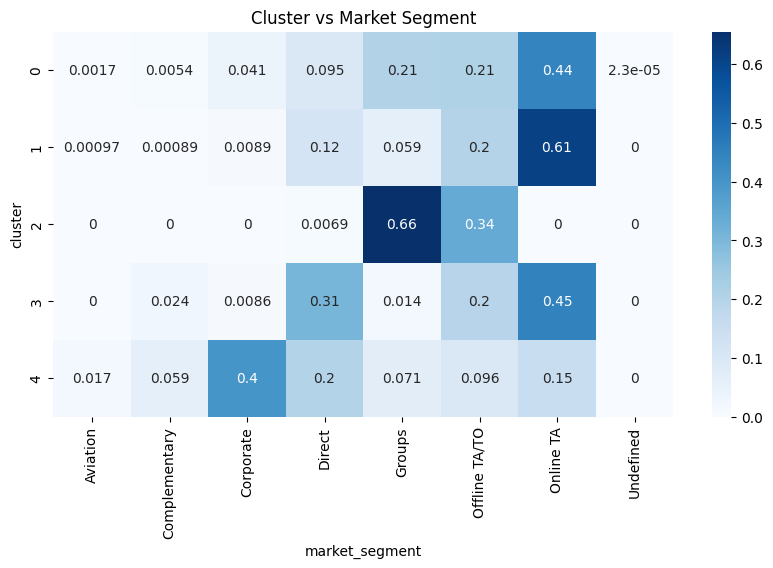

In [45]:
ct = pd.crosstab(df_clustered['cluster'], df_clustered['market_segment'], normalize='index')

plt.figure(figsize=(10,5))
sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Cluster vs Market Segment")
plt.show()

In [46]:
for col in categorical_cols:
    
    profile = (
        df_clustered
        .groupby('cluster')[col]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
        * 100
    )
    
    print(f"\n===== {col} (%) =====")
    print(profile.round(2))


===== hotel (%) =====
hotel    City Hotel  Resort Hotel
cluster                          
0             75.60         24.40
1             41.10         58.90
2              8.97         91.03
3             39.81         60.19
4             53.15         46.85

===== arrival_date_month (%) =====
arrival_date_month  April  August  December  February  January   July  June  \
cluster                                                                       
0                    9.46    9.64      5.74      7.19     5.31   8.83  9.25   
1                    9.12   18.30      5.07      4.92     3.24  16.35  9.26   
2                    7.59    0.00      0.00      0.69     0.00  17.24  0.00   
3                    5.72   21.04      8.31      6.04     4.10  12.84  7.44   
4                    7.43    5.70      8.27     10.92    10.37   7.90  7.30   

arrival_date_month  March    May  November  October  September  
cluster                                                         
0                  